<a href="https://colab.research.google.com/github/ItsSatria29/Brugada-ecg-detector/blob/main/Copy_of_IDSC_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **SETUP & DATA INGESTION**
Menyiapkan environment di Google Colab dan mengunduh dataset mentah dari PhysioNet.

In [1]:
# Install wfdb buat baca format data medis.
# Pandas gw kunci di versi 2.2.2 biar ntar environment Colab nggak tiba-tiba eror karena masalah update versi.
!pip install wfdb pandas==2.2.2

# Unduh dataset zip
!wget -q -O brugada_dataset.zip https://physionet.org/content/brugada-huca/get-zip/1.0.0/

# Ekstrak file zip
!unzip -q -o brugada_dataset.zip -d brugada_data/

import os
import wfdb
import pandas as pd
import matplotlib.pyplot as plt

# Memperbaiki path ke folder hasil ekstraksi yang benar
base_dir = 'brugada_data/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0'
print("Setup selesai. Isi direktori dataset:", os.listdir(base_dir))

INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 4.8 MB/s eta 0:00:00
Setup selesai. Isi direktori dataset: ['files', 'SHA256SUMS.txt', 'metadata_dictionary.csv', 'files.zip', 'metadata.csv', 'README.md', 'RECORDS', 'LICENSE.txt']


### **SANITY CHECK**
Mastiin file zip-nya beneran utuh ke-donlot dan udah terekstrak dengan bener sebelum kita mulai ngoding yang berat-berat.

In [2]:
import os

# Cek ukuran file zip yang sedang diunduh
zip_file = 'brugada_dataset.zip'
if os.path.exists(zip_file):
    size_mb = os.path.getsize(zip_file) / (1024 * 1024)
    print(f'Ukuran file {zip_file}: {size_mb:.2f} MB')
else:
    print('File zip belum ditemukan.')

# Cek apakah folder data sudah mulai terisi
data_dir = 'brugada_data'
if os.path.exists(data_dir):
    files = os.listdir(data_dir)
    print(f'Jumlah item di dalam folder {data_dir}: {len(files)}')
    if len(files) > 0:
        print('Beberapa file yang sudah ada:', files[:5])
else:
    print('Folder data belum dibuat.')

Ukuran file brugada_dataset.zip: 14.42 MB
Jumlah item di dalam folder brugada_data: 1
Beberapa file yang sudah ada: ['brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0']


### **LOAD METADATA & LABELING**
Baca file CSV buat nyari tau pasien mana yang Brugada, mana yang Normal. Ini kemungkinan bakal jadi target (y) buat model kita ntar.

In [3]:
# Path ke file metadata. (Perlu dicek nama file pastinya setelah diekstrak)
# TODO: Pastikan nama file CSV-nya benar (bisa jadi subject_info.csv atau metadata.csv)
csv_path = f'{base_dir}/metadata.csv'

try:
    # Membaca CSV menggunakan pandas
    df_metadata = pd.read_csv(csv_path)
    print("Metadata berhasil dimuat!")

    # Menampilkan 5 data pertama untuk inspeksi (Exploratory Data Analysis awal)
    display(df_metadata.head())

    # Cek distribusi kelas (Brugada vs Normal) untuk melihat seberapa imbalance datanya
    # print(df_metadata['diagnosis_column_name'].value_counts())

except FileNotFoundError:
    print(f"ERROR: File {csv_path} tidak ditemukan. Tolong cek nama file CSV di dalam folder.")

Metadata berhasil dimuat!


,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


### **EKSTRAK FITUR (SINYAL EKG) & VISUALISASI**

Mencari file .hea secara otomatis di dalam sub-folder apapun
menggunakan glob, lalu memvisualisasikan sampel pertamanya.

Mencari file .hea...
Berhasil menemukan 363 file rekaman EKG!

--- INFORMASI SINYAL (SAMPEL PERTAMA) ---
Path Asli: brugada_data/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0/files/3015438/3015438.hea
ID Pasien / Record: 3015438
Sampling Frequency: 100 Hz
Shape Matriks Sinyal: (1200, 12)


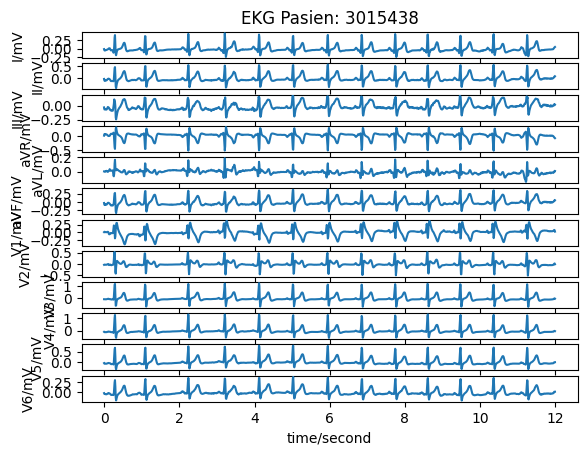

In [4]:
import glob


print("Mencari file .hea...")
# Mencari semua file .hea di dalam base_dir dan sub-foldernya
all_hea_files = glob.glob(f'{base_dir}/**/*.hea', recursive=True)

if all_hea_files:
    print(f"Berhasil menemukan {len(all_hea_files)} file rekaman EKG!")

    # Ambil file pertama yang ditemukan untuk sampel
    sample_path_full = all_hea_files[0]

    # Membuang 4 karakter terakhir ('.hea') untuk mendapatkan path murni yang dibutuhkan wfdb
    sample_path = sample_path_full[:-4]

    try:
        # Membaca data sinyal
        record = wfdb.rdrecord(sample_path)
        print("\n--- INFORMASI SINYAL (SAMPEL PERTAMA) ---")
        print(f"Path Asli: {sample_path_full}")
        print(f"ID Pasien / Record: {record.record_name}")
        print(f"Sampling Frequency: {record.fs} Hz")

        # Fitur X kita nanti ukurannya ada di sini
        print(f"Shape Matriks Sinyal: {record.p_signal.shape}")

        # Visualisasi
        wfdb.plot_wfdb(record=record, title=f"EKG Pasien: {record.record_name}")

    except Exception as e:
        print(f"Gagal membaca record: {e}")
else:
    print(f"ERROR: Tidak ada file .hea ditemukan di dalam direktori {base_dir}")

    # Mode Debugging: Intip isi folder files/ jika glob gagal
    files_path = f'{base_dir}/files'
    if os.path.exists(files_path):
        print("\n[DEBUG] Intip isi folder files/:", os.listdir(files_path)[:5])
    else:
        print(f"\n[DEBUG] Folder {files_path} tidak ditemukan juga.")

# **PREPROCESSING (FILTERING)**
Sinyal EKG mentah sangat rentan terhadap *noise* (gangguan). Ada *baseline wander* (garis yang naik-turun karena napas pasien) dan *high-frequency noise* (karena kontraksi otot atau gangguan listrik 50/60Hz).
        
Solusi: Kita gunakan **Bandpass Filter** (0.5 Hz - 45.0 Hz). Tujuannya agar model AI tidak kebingungan dan hanya fokus belajar dari pola gelombang jantung yang murni dan bersih.

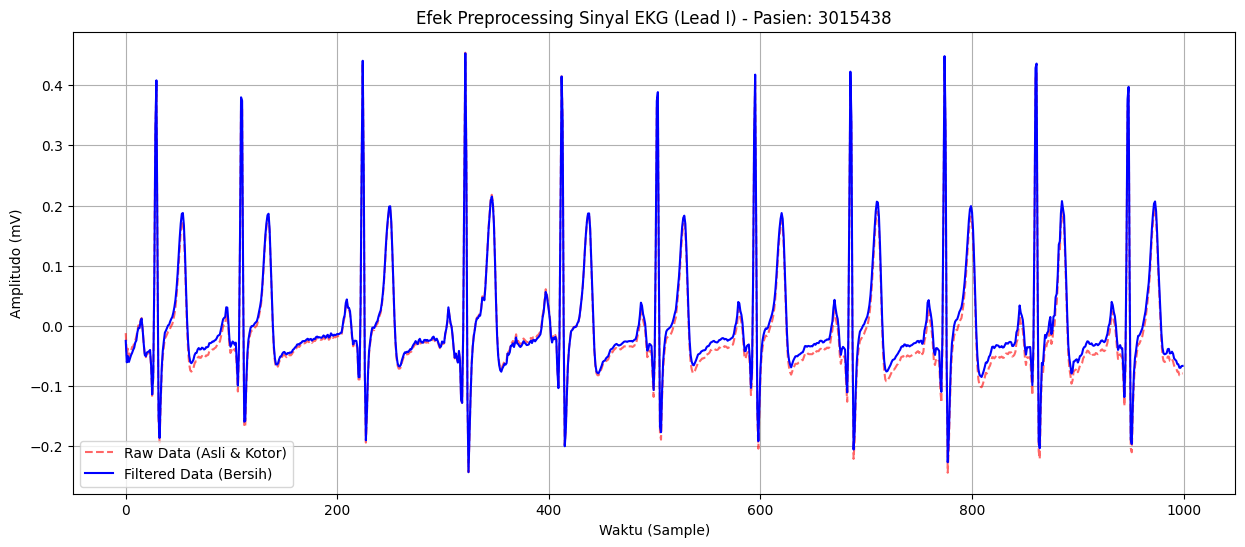

In [5]:
from scipy.signal import butter, filtfilt
import numpy as np

def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=250, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # Menghindari error pembagian nol jika rentang frekuensi tidak valid
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# Ambil satu channel saja untuk uji coba (misal Lead I, index 0)
raw_signal = record.p_signal[:, 0]
fs = record.fs # Mengambil frekuensi sampling asli dari metadata record

# Terapkan filter
filtered_signal = bandpass_filter(raw_signal, fs=fs)

# Plot perbandingan Sebelum vs Sesudah Filter (1000 titik pertama saja agar jelas)
plt.figure(figsize=(15, 6))
plt.plot(raw_signal[:1000], label='Raw Data (Asli & Kotor)', alpha=0.6, color='red', linestyle='--')
plt.plot(filtered_signal[:1000], label='Filtered Data (Bersih)', linewidth=1.5, color='blue')
plt.title(f"Efek Preprocessing Sinyal EKG (Lead I) - Pasien: {record.record_name}")
plt.xlabel("Waktu (Sample)")
plt.ylabel("Amplitudo (mV)")
plt.legend()
plt.grid(True)
plt.show()

# **EKSTRAKSI DETAK (SEGMENTASI R-PEAK)**
**Deteksi R-Peak:** Kita menggunakan pustaka `neurokit2` untuk secara otomatis mencari **Puncak R** (lonjakan tertinggi pada detak jantung) yang akan dijadikan sebagai titik acuan (titik tengah).
**Pemotongan (Windowing):**
Sinyal dipotong dari **0.2 detik sebelum** hingga **0.4 detik sesudah** puncak R. Rentang setelah puncak R sangat penting karena di sanalah **Segmen ST** berada, yaitu tempat munculnya ciri khas kelainan Sindrom Brugada. Melalui segmentasi ini, AI nantinya akan sangat fokus meneliti lekukan gelombang pada area spesifik tersebut.
**Menumpuk Detak Jantung (Stacking):**
Setelah dipotong, potongan-potongan sinyal EKG tersebut "ditumpuk" sejajar (semua puncak R berada di sumbu tengah yang sama) menjadi sebuah matriks 2D.
Hal ini dilakukan agar AI 1D-CNN mendapatkan input yang panjangnya seragam, sekaligus mempermudah AI untuk fokus mendeteksi anomali pada lekukan gelombang tanpa terpengaruh oleh seberapa lama pasien tersebut direkam.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 10.0 MB/s eta 0:00:00

--- TAHAP 3: DETEKSI R-PEAK & SEGMENTASI ---
Ditemukan 12 detak jantung pada sampel rekaman ini.
Shape Kumpulan Detak: (12, 60) -> (Jumlah Detak, Panjang Sinyal Fitur)


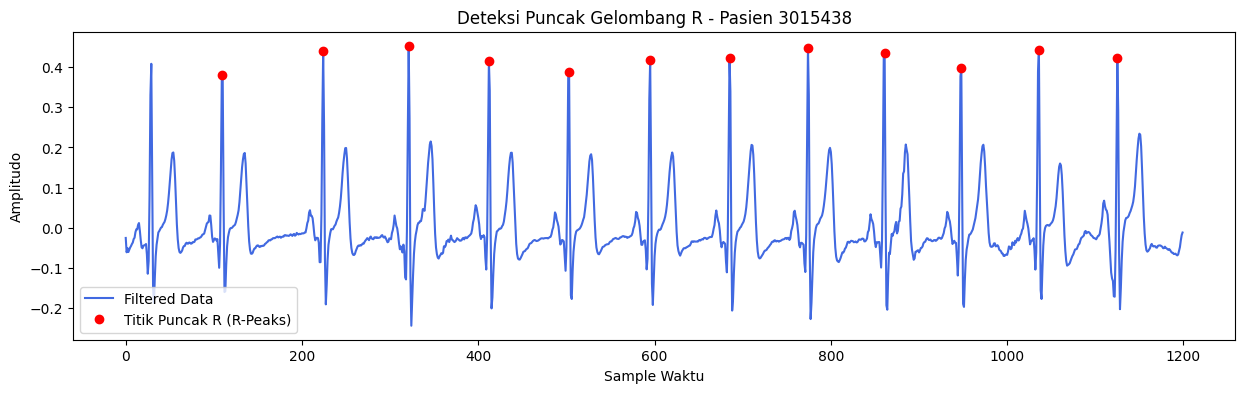

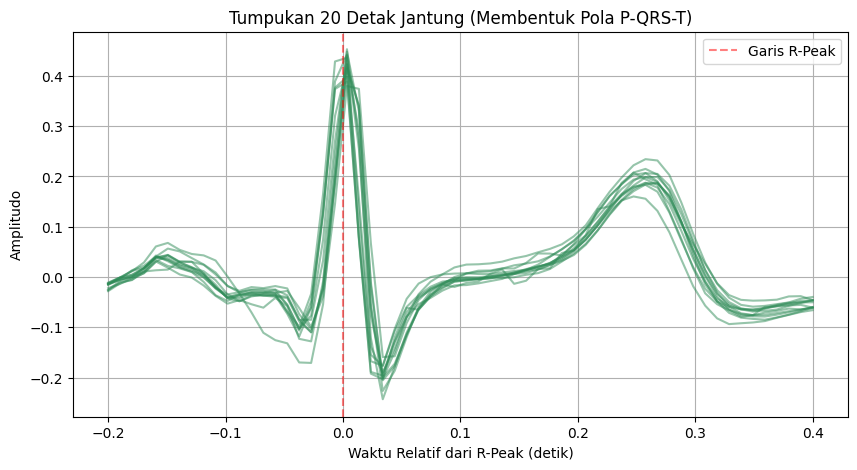

In [6]:
!pip install neurokit2
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt

print("\n--- TAHAP 3: DETEKSI R-PEAK & SEGMENTASI ---")

# 1. Cari letak index puncak gelombang R
# neurokit otomatis mendeteksi puncak berdasarkan algoritma pakar
_, rpeaks = nk.ecg_peaks(filtered_signal, sampling_rate=fs)
r_indices = rpeaks['ECG_R_Peaks']

print(f"Ditemukan {len(r_indices)} detak jantung pada sampel rekaman ini.")

# 2. Segmentasi: Memotong -0.2 detik (sebelum) s/d +0.4 detik (sesudah) puncak R
# Hitung jumlah sampel (titik) berdasarkan sampling rate
window_sebelum = int(0.2 * fs)
window_sesudah = int(0.4 * fs)

heartbeats = []
for r in r_indices:
    start_idx = r - window_sebelum
    end_idx = r + window_sesudah

    # Hanya ambil potongan detak jika tidak melewati batas array awal/akhir
    if start_idx >= 0 and end_idx < len(filtered_signal):
        potongan = filtered_signal[start_idx:end_idx]
        heartbeats.append(potongan)

# Ubah ke numpy array agar siap masuk Machine Learning
heartbeats = np.array(heartbeats)
print(f"Shape Kumpulan Detak: {heartbeats.shape} -> (Jumlah Detak, Panjang Sinyal Fitur)")

# ------------------- VISUALISASI TAHAP 3 -------------------
# Gambar A: Membuktikan R-Peak terdeteksi dengan benar
plt.figure(figsize=(15, 4))
batas_plot = 2000 # Cukup tampilkan 2000 data pertama
plt.plot(filtered_signal[:batas_plot], label='Filtered Data', color='royalblue')

# Ambil titik R-Peak yang hanya berada dalam batas_plot
r_tampil = [r for r in r_indices if r < batas_plot]
plt.plot(r_tampil, filtered_signal[r_tampil], 'ro', label='Titik Puncak R (R-Peaks)')
plt.title(f"Deteksi Puncak Gelombang R - Pasien {record.record_name}")
plt.xlabel("Sample Waktu")
plt.ylabel("Amplitudo")
plt.legend()
plt.show()

# Gambar B: Menumpuk detak jantung untuk melihat pola
plt.figure(figsize=(10, 5))
# Buat sumbu X dari -0.2 s/d 0.4 detik
waktu_x = np.linspace(-0.2, 0.4, window_sebelum + window_sesudah)

# Plot maksimal 20 detak saja agar tidak terlalu padat
for i in range(min(20, len(heartbeats))):
    plt.plot(waktu_x, heartbeats[i], alpha=0.5, color='seagreen')

plt.title("Tumpukan 20 Detak Jantung (Membentuk Pola P-QRS-T)")
plt.xlabel("Waktu Relatif dari R-Peak (detik)")
plt.ylabel("Amplitudo")
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Garis R-Peak')
plt.legend()
plt.grid(True)
plt.show()

# **BATCH PROCESSING & TRAINING SVM**
Alasan menggunakan model SVM karena SVM punya fitur bawaan (class_weight) yang otomatis menghukum model jika melewatkan pasien Brugada yang jumlah datanya sangat sedikit.

In [7]:
from sklearn.svm import SVC
from sklearn.utils import compute_class_weight
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
import glob
from scipy.signal import butter, filtfilt
import os

# Mendefinisikan X_train, X_val, y_train, y_val

# Re-define bandpass_filter function untuk memastikan ketersediaan
def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=None, order=5):
    if fs is None:
        raise ValueError("Sampling frequency (fs) must be provided for filtering.")
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    if not (0 < low < high < 1):
        # Ini adalah pengecekan untuk memastikan parameter filter valid
        raise ValueError(f"Invalid filter frequencies for fs={fs}. Normalized cutoffs: low={low:.4f}, high={high:.4f}. Must satisfy 0 < low < high < 1.")

    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# List global untuk menyimpan semua detak jantung yang diproses dan labelnya
all_features = []
all_labels = []

# Variabel base_dir, df_metadata, dan all_hea_files tersedia dari cell sebelumnya

print("Memulai pemrosesan batch data EKG...")

for hea_file_full_path in all_hea_files:
    # Ekstrak patient_id dari path file
    # Contoh path: brugada_data/.../files/1135434/1135434.hea
    patient_id_str = os.path.basename(os.path.dirname(hea_file_full_path))

    if not patient_id_str.isdigit():
        print(f"Melewatkan file {hea_file_full_path}: Tidak dapat mengekstrak ID pasien yang valid.")
        continue

    patient_id = int(patient_id_str)

    # Dapatkan label dari df_metadata
    label_row = df_metadata[df_metadata['patient_id'] == patient_id]

    if label_row.empty:
        print(f"Peringatan: ID Pasien {patient_id} tidak ditemukan di metadata. Melewatkan rekaman: {hea_file_full_path}")
        continue

    # Asumsikan 'brugada' adalah kolom dengan diagnosis biner (0 untuk Normal, 1 untuk Brugada)
    label = label_row['brugada'].iloc[0]

    # Baca rekaman
    record_path = hea_file_full_path[:-4] # Hapus ekstensi .hea
    try:
        record = wfdb.rdrecord(record_path)
    except Exception as e:
        print(f"Gagal membaca rekaman {record_path}: {e}. Melewatkan.")
        continue

    fs = record.fs # Dapatkan frekuensi sampling aktual untuk rekaman ini

    # Perbarui ukuran window berdasarkan fs rekaman saat ini
    current_window_sebelum = int(0.2 * fs)
    current_window_sesudah = int(0.4 * fs)

    if record.p_signal is None:
        print(f"Peringatan: Tidak ada data sinyal untuk rekaman {record_path}. Melewatkan.")
        continue

    # Estimasi kasar panjang sinyal minimum yang dibutuhkan untuk deteksi R-peak yang andal
    min_signal_length = fs * 2
    if record.p_signal.shape[0] < min_signal_length:
        print(f"Peringatan: Rekaman {record_path} terlalu pendek ({record.p_signal.shape[0]} sampel) untuk deteksi R-peak yang andal. Melewatkan.")
        continue

    processed_leads_data = [] # List untuk menyimpan data lead yang diproses
    processed_leads_indices = [] # List untuk menyimpan indeks asli lead yang diproses

    num_leads_in_record = record.p_signal.shape[1]
    num_expected_leads = 12 # Standar EKG 12-lead

    for i in range(num_leads_in_record): # Iterasi melalui lead
        raw_signal_lead = record.p_signal[:, i]

        # Terapkan filter bandpass
        try:
            filtered_signal_lead = bandpass_filter(raw_signal_lead, fs=fs)
        except ValueError as e:
            print(f"Error filtering sinyal untuk rekaman {record_path}, lead {i}: {e}. Melewatkan lead ini.")
            continue

        # Deteksi R-peak
        try:
            _, rpeaks = nk.ecg_peaks(filtered_signal_lead, sampling_rate=fs)
            r_indices = rpeaks['ECG_R_Peaks']
        except Exception as e:
            print(f"Error mendeteksi R-peaks untuk rekaman {record_path}, lead {i}: {e}. Melewatkan lead ini.")
            continue

        heartbeats_lead = []
        for r in r_indices:
            start_idx = r - current_window_sebelum
            end_idx = r + current_window_sesudah

            if start_idx >= 0 and end_idx < len(filtered_signal_lead):
                potongan = filtered_signal_lead[start_idx:end_idx]
                # Pastikan panjang potongan konsisten
                if len(potongan) == (current_window_sebelum + current_window_sesudah):
                    heartbeats_lead.append(potongan)

        if heartbeats_lead:
            processed_leads_data.append(heartbeats_lead)
            processed_leads_indices.append(i) # Simpan indeks lead asli

    if not processed_leads_data:
        print(f"Peringatan: Tidak ada detak jantung valid yang ditemukan untuk rekaman {record_path} di semua lead setelah pemrosesan. Melewatkan pasien.")
        continue

    # Temukan jumlah detak jantung minimum yang terdeteksi di antara semua lead yang berhasil diproses
    min_heartbeats_per_lead = min(len(hb_list) for hb_list in processed_leads_data)

    # Pastikan semua segmen memiliki panjang yang sama.
    segment_length = current_window_sebelum + current_window_sesudah

    if min_heartbeats_per_lead > 0:
        # Inisialisasi dengan nol untuk semua 12 lead untuk memastikan dimensi channel yang konsisten
        patient_3d_features = np.zeros((min_heartbeats_per_lead, segment_length, num_expected_leads))

        for lead_idx_in_processed, original_lead_channel in enumerate(processed_leads_indices):
            lead_data = processed_leads_data[lead_idx_in_processed]
            # Ambil hanya min_heartbeats_per_lead dari setiap lead dan letakkan di posisi channel aslinya
            for hb_idx in range(min_heartbeats_per_lead):
                patient_3d_features[hb_idx, :, original_lead_channel] = lead_data[hb_idx]

        # Tambahkan semua detak jantung individu dari pasien ini ke list global dengan labelnya
        for heartbeat_3d_segment in patient_3d_features:
            all_features.append(heartbeat_3d_segment)
            all_labels.append(label)
    else:
        print(f"Peringatan: Tidak ada detak jantung dengan jumlah minimum yang ditemukan untuk rekaman {record_path} setelah pemrosesan. Melewatkan pasien.")

# Konversi ke numpy array
X_all = np.array(all_features)
y_all = np.array(all_labels)

print(f"\nTotal detak jantung terkumpul (bentuk X_all): {X_all.shape}")
print(f"Total label terkumpul (bentuk y_all): {y_all.shape}")
print(f"Distribusi label: {np.unique(y_all, return_counts=True)}")


# Bagi menjadi set pelatihan dan validasi
# Gunakan stratify untuk menjaga distribusi kelas, sangat penting untuk dataset yang tidak seimbang
X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f"\nBentuk X_train: {X_train.shape}")
print(f"Bentuk X_val: {X_val.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk y_val: {y_val.shape}")

# --- Akhir dari kode tambahan ---

# 1. Reshape X_train dari format 3D (samples, timesteps, channels) ke format 2D (samples, timesteps * channels)
samples_train, timesteps_train, channels_train = X_train.shape
X_train_svm = X_train.reshape(samples_train, timesteps_train * channels_train)

# 2. Lakukan hal yang sama untuk X_val, reshape dari format 3D ke 2D
samples_val, timesteps_val, channels_val = X_val.shape
X_val_svm = X_val.reshape(samples_val, timesteps_val * channels_val)

# 3. Cetak bentuk (shape) dari X_train_svm dan X_val_svm untuk memverifikasi
print(f"Bentuk X_train_svm: {X_train_svm.shape}")
print(f"Bentuk X_val_svm: {X_val_svm.shape}")

# Hitung bobot kelas untuk menangani ketidakseimbangan
class_weights_svm = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
unique_classes = np.unique(y_train)
class_weight_dict_svm = {cls: weight for cls, weight in zip(unique_classes, class_weights_svm)}


print(f"Bobot kelas untuk SVM: {class_weight_dict_svm}")

# Inisialisasi dan latih model SVC
svm_model = SVC(kernel='rbf', class_weight=class_weight_dict_svm, random_state=42, probability=True)
print("\nMelatih model SVM...")
svm_model.fit(X_train_svm, y_train)

print("✅ Model SVM berhasil dilatih!")


Memulai pemrosesan batch data EKG...

Total detak jantung terkumpul (bentuk X_all): (4711, 60, 12)
Total label terkumpul (bentuk y_all): (4711,)
Distribusi label: (array([0, 1, 2]), array([3711,  911,   89]))

Bentuk X_train: (3768, 60, 12)
Bentuk X_val: (943, 60, 12)
Bentuk y_train: (3768,)
Bentuk y_val: (943,)
Bentuk X_train_svm: (3768, 720)
Bentuk X_val_svm: (943, 720)
Bobot kelas untuk SVM: {np.int64(0): np.float64(0.42318059299191374), np.int64(1): np.float64(1.7229080932784637), np.int64(2): np.float64(17.690140845070424)}

Melatih model SVM...
✅ Model SVM berhasil dilatih!


# **Model Evaluation & Performance Analysis**

### Subtask:
Evaluate the SVM model's performance on X_val by calculating and displaying its accuracy, classification report, and confusion matrix, and compare these results with the previously obtained CNN model's performance.

Running predictions on validation data using SVM model...

SVM Validation Accuracy: 0.9692

SVM Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.99      0.97      0.98       743
 Brugada (1)       0.88      0.98      0.92       182

   micro avg       0.97      0.97      0.97       925
   macro avg       0.94      0.97      0.95       925
weighted avg       0.97      0.97      0.97       925



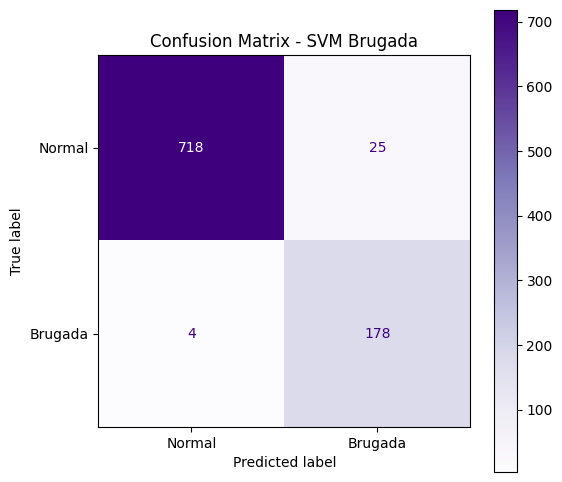

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("### Subtask:\nEvaluate the SVM model's performance on X_val by calculating and displaying its accuracy, classification report, and confusion matrix, and compare these results with the previously obtained CNN model's performance.")

print("\nRunning predictions on validation data using SVM model...")
# Predict on the validation set
y_pred_svm = svm_model.predict(X_val_svm)

# Calculate overall accuracy
acc_svm = accuracy_score(y_val, y_pred_svm)
print(f"\nSVM Validation Accuracy: {acc_svm:.4f}")

# Print the detailed classification report
print("\nSVM Classification Report:")
# Ensure target_names and labels match the unique values in y_val and y_pred_svm
print(classification_report(y_val, y_pred_svm, target_names=['Normal (0)', 'Brugada (1)'], labels=[0, 1]))

# Plot the confusion matrix
cm_svm = confusion_matrix(y_val, y_pred_svm, labels=[0, 1])
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Normal', 'Brugada'])

plt.figure(figsize=(6, 6))
disp_svm.plot(cmap='Purples', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix - SVM Brugada")
plt.show()

### **Deploy Dashboard**

In [9]:
!pip install streamlit wfdb neurokit2 scipy scikit-learn joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 34.3 MB/s eta 0:00:00


In [10]:
%%writefile mock_pipeline.py
"""
mock_pipeline.py
"""
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt


def read_wfdb_record(record_path: str):
    import wfdb
    return wfdb.rdrecord(record_path)


def get_lead_signal(record, lead_idx: int = 0):
    signal = record.p_signal[:, lead_idx].astype(float)
    nans = np.isnan(signal)
    if nans.any():
        idx = np.arange(len(signal))
        signal[nans] = np.interp(idx[nans], idx[~nans], signal[~nans])
    return signal, float(record.fs), record.sig_name[lead_idx]


def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=250, order=5):
    if fs is None:
        raise ValueError("fs must be provided")
    nyq  = 0.5 * fs
    low  = lowcut  / nyq
    high = highcut / nyq
    if not (0 < low < high < 1):
        raise ValueError(f"Invalid filter frequencies for fs={fs}")
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data)


def detect_rpeaks(filtered_signal, fs):
    try:
        import neurokit2 as nk
        _, rpeaks_dict = nk.ecg_peaks(filtered_signal, sampling_rate=int(fs))
        return rpeaks_dict["ECG_R_Peaks"], "neurokit2"
    except Exception:
        from scipy.signal import find_peaks
        thr = np.mean(filtered_signal) + 1.5 * np.std(filtered_signal)
        peaks, _ = find_peaks(filtered_signal, height=thr, distance=int(fs * 0.4))
        return peaks, "scipy_fallback"


def process_all_leads(record, before_sec=0.2, after_sec=0.4,
                      lowcut=0.5, highcut=45.0):
    """
    Proses semua 12 lead dari satu record — persis seperti Cell 13 notebook.
    Returns: (heartbeats_3d, r_indices, rpeak_method, fs)
      heartbeats_3d shape: (n_beats, timesteps, 12)
    """
    fs = float(record.fs)
    num_expected_leads = 12
    w_pre  = int(before_sec * fs)
    w_post = int(after_sec  * fs)
    seg_len = w_pre + w_post

    num_leads = record.p_signal.shape[1]
    processed_leads_data    = []
    processed_leads_indices = []
    r_indices_ref  = None
    rpeak_method   = "neurokit2"

    for i in range(num_leads):
        raw = record.p_signal[:, i].astype(float)
        nans = np.isnan(raw)
        if nans.any():
            idx = np.arange(len(raw))
            raw[nans] = np.interp(idx[nans], idx[~nans], raw[~nans])

        try:
            filt = bandpass_filter(raw, lowcut=lowcut, highcut=highcut, fs=fs)
        except Exception:
            continue

        try:
            r_idx, method = detect_rpeaks(filt, fs)
        except Exception:
            continue

        # Gunakan lead pertama sebagai referensi R-peak
        if r_indices_ref is None:
            r_indices_ref = r_idx
            rpeak_method  = method

        beats = []
        for r in r_indices_ref:
            s, e = r - w_pre, r + w_post
            if s >= 0 and e < len(filt) and (e - s) == seg_len:
                beats.append(filt[s:e])

        if beats:
            processed_leads_data.append(beats)
            processed_leads_indices.append(i)

    if not processed_leads_data or r_indices_ref is None:
        return np.empty((0, seg_len, num_expected_leads)), np.array([]), rpeak_method, fs

    min_beats = min(len(b) for b in processed_leads_data)
    heartbeats_3d = np.zeros((min_beats, seg_len, num_expected_leads))

    for idx_in_proc, orig_ch in enumerate(processed_leads_indices):
        ch = min(orig_ch, num_expected_leads - 1)
        for hb_idx in range(min_beats):
            heartbeats_3d[hb_idx, :, ch] = processed_leads_data[idx_in_proc][hb_idx]

    return heartbeats_3d, r_indices_ref, rpeak_method, fs


def prepare_svm_input(heartbeats_3d):
    """
    Flatten (n_beats, timesteps, channels) → (n_beats, timesteps * channels)
    Sama persis dengan reshape di Cell 13 notebook.
    """
    n, t, c = heartbeats_3d.shape
    return heartbeats_3d.reshape(n, t * c).astype(np.float32)


def segment_heartbeats_1lead(signal, r_indices, fs, before_sec=0.2, after_sec=0.4):
    """Segmentasi 1 lead saja — untuk keperluan visualisasi."""
    w_pre  = int(before_sec * fs)
    w_post = int(after_sec  * fs)
    beats  = []
    for r in r_indices:
        s, e = r - w_pre, r + w_post
        if s >= 0 and e < len(signal):
            beats.append(signal[s:e])
    if not beats:
        return np.empty((0, w_pre + w_post))
    return np.array(beats)


class MockSVMModel:
    THRESHOLD_MEAN = 0.80
    THRESHOLD_STD  = 0.25

    def _score(self, row):
        m = float(np.mean(row))
        s = float(np.std(row))
        return float(np.clip(
            (m / (self.THRESHOLD_MEAN * 2) + s / (self.THRESHOLD_STD * 2)) / 2,
            0.0, 1.0
        ))

    def predict(self, X):
        return np.array([1 if self._score(r) > 0.5 else 0 for r in X])

    def predict_proba(self, X):
        scores = np.array([self._score(r) for r in X])
        return np.column_stack([1 - scores, scores])


def load_model(model_path="../models/svm_model.pkl"):
    if os.path.exists(model_path):
        import joblib
        return joblib.load(model_path), False
    return MockSVMModel(), True

Writing mock_pipeline.py


In [11]:
%%writefile app.py
import os
import glob
import tempfile
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import streamlit as st

warnings.filterwarnings("ignore")
matplotlib.use("Agg")

from mock_pipeline import (
    read_wfdb_record, get_lead_signal, bandpass_filter,
    detect_rpeaks, segment_heartbeats_1lead,
    process_all_leads, prepare_svm_input, load_model,
)

st.set_page_config(page_title="Brugada ECG · AI Detector", page_icon="🫀", layout="wide")

st.markdown("""
<style>
html, body, [class*="css"] {
    font-family: 'Trebuchet MS', 'Segoe UI', sans-serif;
    background-color: #080f1a; color: #cdd9e5;
}
[data-testid="stSidebar"] { background-color: #0d1826; border-right: 1px solid #1e2d40; }
[data-testid="stSidebar"] * { color: #a8bbd1 !important; }
.dash-header {
    background: linear-gradient(160deg, #05101f 0%, #0a2038 60%, #091828 100%);
    border: 1px solid #1e3a55; border-radius: 14px;
    padding: 30px 40px; margin-bottom: 30px;
    display: flex; align-items: center; gap: 22px;
}
.dash-title { font-family: 'Courier New', monospace; font-size: 1.9rem; font-weight: 600; color: #4fc3f7; margin: 0; }
.dash-sub { font-size: 0.84rem; color: #607d8b; margin: 5px 0 0; font-family: 'Courier New', monospace; }
.step-label { display: flex; align-items: center; gap: 10px; margin-bottom: 14px; }
.step-num {
    background: #0d2438; color: #4fc3f7; border: 1px solid #1e4060;
    border-radius: 6px; padding: 2px 10px;
    font-family: 'Courier New', monospace; font-size: 0.7rem;
    letter-spacing: 2px; text-transform: uppercase;
}
.step-desc { color: #607d8b; font-size: 0.83rem; font-family: 'Courier New', monospace; }
.result-box { background: #0d1826; border-radius: 14px; padding: 36px 20px; text-align: center; margin-bottom: 24px; }
.badge-normal {
    display: inline-block; background: #0a2e1a; color: #56d364;
    border: 2px solid #2ea043; border-radius: 30px; padding: 10px 36px;
    font-family: 'Courier New', monospace; font-size: 1.3rem; font-weight: 600; letter-spacing: 2px;
}
.badge-brugada {
    display: inline-block; background: #2d0d0d; color: #ff7b72;
    border: 2px solid #cf222e; border-radius: 30px; padding: 10px 36px;
    font-family: 'Courier New', monospace; font-size: 1.3rem; font-weight: 600; letter-spacing: 2px;
}
.badge-demo {
    display: inline-block; background: #2a1f08; color: #e3b341;
    border: 1px solid #9e6a03; border-radius: 14px; padding: 3px 12px;
    font-family: 'Courier New', monospace; font-size: 0.68rem; margin-left: 10px; vertical-align: middle;
}
[data-testid="metric-container"] {
    background: #0d1826 !important; border: 1px solid #1e2d40 !important;
    border-radius: 10px !important; padding: 16px 20px !important;
}
[data-testid="metric-container"] label {
    font-family: 'Courier New', monospace !important; font-size: 0.68rem !important;
    letter-spacing: 1.5px !important; text-transform: uppercase !important; color: #607d8b !important;
}
[data-testid="metric-container"] [data-testid="stMetricValue"] {
    font-family: 'Courier New', monospace !important; font-size: 1.55rem !important; color: #4fc3f7 !important;
}
hr { border-color: #1e2d40; margin: 28px 0; }
</style>
""", unsafe_allow_html=True)

MPL = {
    "figure.facecolor": "#080f1a", "axes.facecolor": "#0d1826",
    "axes.edgecolor": "#1e2d40", "axes.labelcolor": "#607d8b",
    "xtick.color": "#607d8b", "ytick.color": "#607d8b",
    "grid.color": "#152030", "text.color": "#cdd9e5", "lines.linewidth": 1.3,
}

def mpl_fig(*args, **kwargs):
    with plt.rc_context(MPL):
        fig, ax = plt.subplots(*args, **kwargs)
    fig.patch.set_facecolor("#080f1a")
    return fig, ax

def step(num, desc):
    st.markdown(
        f'<div class="step-label"><span class="step-num">STEP {num}</span>'
        f'<span class="step-desc">{desc}</span></div>',
        unsafe_allow_html=True,
    )

def save_wfdb_files(hea_file, dat_file):
    tmp = tempfile.mkdtemp()
    for f in [hea_file, dat_file]:
        with open(os.path.join(tmp, f.name), "wb") as out:
            out.write(f.getbuffer())
    return os.path.join(tmp, hea_file.name.replace(".hea", ""))

def save_zip_record(zip_file):
    tmp = tempfile.mkdtemp()
    with zipfile.ZipFile(zip_file) as zf:
        zf.extractall(tmp)
    for root, _, files in os.walk(tmp):
        for f in files:
            if f.endswith(".hea"):
                return os.path.join(root, f[:-4]), tmp
    return None, tmp

@st.cache_resource(show_spinner=False)
def cached_model(path):
    return load_model(path)

# ── Header ──────────────────────────────────────────────────
st.markdown("""
<div class="dash-header">
  <div style="font-size:3.2rem;line-height:1">🫀</div>
  <div>
    <p class="dash-title">Brugada ECG · AI Detector</p>
    <p class="dash-sub">wfdb → bandpass filter → R-peak → SVM · IDSC 2026</p>
  </div>
</div>
""", unsafe_allow_html=True)

# ── Sidebar ──────────────────────────────────────────────────
with st.sidebar:
    st.markdown("### ⚙️ Pipeline Settings")
    st.markdown("---")
    st.markdown("**Filter**")
    apply_filter = st.checkbox("Apply bandpass filter", value=True)
    low_cut  = st.slider("Low cut (Hz)",  0.1, 2.0, 0.5, 0.1)
    high_cut = st.slider("High cut (Hz)", 20.0, 100.0, 45.0, 1.0)
    st.markdown("---")
    st.markdown("**Segmentation**")
    before_ms = st.slider("Window before R-peak (ms)", 100, 400, 200, 10)
    after_ms  = st.slider("Window after R-peak (ms)", 200, 800, 400, 10)
    st.markdown("---")
    st.markdown("**Visualization**")
    lead_idx       = st.number_input("Lead index (for plot)", 0, 11, 0)
    max_beats_plot = st.slider("Max beats overlay", 5, 50, 20)
    st.markdown("---")
    st.markdown("**Model**")
    model_path = st.text_input("SVM path (.pkl)", "../models/svm_model.pkl")

# ── Source Selection ─────────────────────────────────────────
st.markdown("#### Select ECG Record")
source_mode = st.radio(
    "Source",
    ["📁 Local Dataset (Colab)", "⬆️ Upload .hea + .dat", "⬆️ Upload .zip"],
    horizontal=True, label_visibility="collapsed"
)

record_path = None

if source_mode == "📁 Local Dataset (Colab)":
    BASE_DIR = "brugada_data/brugada-huca-12-lead-ecg-recordings-for-the-study-of-brugada-syndrome-1.0.0"
    all_hea  = sorted(glob.glob(f"{BASE_DIR}/**/*.hea", recursive=True))
    if not all_hea:
        st.error("❌ Dataset not found. Make sure Cell 1 of the notebook has been run first.")
        st.stop()
    record_names = [os.path.basename(f).replace(".hea", "") for f in all_hea]
    meta_path = f"{BASE_DIR}/metadata.csv"
    df_meta   = None
    if os.path.exists(meta_path):
        try:
            df_meta = pd.read_csv(meta_path)
        except Exception:
            df_meta = None
    if df_meta is not None and "patient_id" in df_meta.columns and "brugada" in df_meta.columns:
        def make_label(name):
            try:
                pid = int(name)
                row = df_meta[df_meta["patient_id"] == pid]
                if not row.empty:
                    tag = "🔴 Brugada" if row["brugada"].values[0] == 1 else "🟢 Normal"
                    return f"{name}  —  {tag}"
            except Exception:
                pass
            return name
        dropdown_labels = [make_label(n) for n in record_names]
    else:
        dropdown_labels = record_names
    st.markdown(f'<p style="color:#607d8b;font-size:0.82rem;font-family:\'Courier New\',monospace;">'
                f'{len(all_hea)} records found in dataset</p>', unsafe_allow_html=True)
    selected_label = st.selectbox("Choose a record:", dropdown_labels)
    selected_idx   = dropdown_labels.index(selected_label)
    record_path    = all_hea[selected_idx][:-4]

elif source_mode == "⬆️ Upload .hea + .dat":
    col1, col2 = st.columns(2)
    hea_file = col1.file_uploader("Upload .hea", type=["hea"])
    dat_file = col2.file_uploader("Upload .dat", type=["dat"])
    if hea_file and dat_file:
        if hea_file.name.replace(".hea", "") != dat_file.name.replace(".dat", ""):
            st.error("❌ File names do not match!"); st.stop()
        record_path = save_wfdb_files(hea_file, dat_file)
    else:
        st.info("Upload the .hea and .dat files from the PhysioNet Brugada dataset.")
        st.stop()
else:
    zip_file = st.file_uploader("Upload .zip", type=["zip"])
    if zip_file:
        record_path, _ = save_zip_record(zip_file)
        if not record_path:
            st.error("❌ No .hea found inside ZIP."); st.stop()
    else:
        st.info("Upload a .zip archive containing the .hea and .dat pair.")
        st.stop()

# ── STEP 1: Load Record ──────────────────────────────────────
with st.spinner("Reading record..."):
    try:
        record = read_wfdb_record(record_path)
    except Exception as e:
        st.error(f"❌ Failed to read record: {e}"); st.stop()

n_leads  = record.p_signal.shape[1]
fs       = float(record.fs)
duration = record.p_signal.shape[0] / fs
rec_name = str(record.record_name)

st.markdown("---")
step("1", "Record Metadata")
c1, c2, c3, c4 = st.columns(4)
c1.metric("Record ID",          rec_name[:14])
c2.metric("Leads",              n_leads)
c3.metric("Sampling Rate (Hz)", int(fs))
c4.metric("Duration (s)",       f"{duration:.1f}")
with st.expander("🗂 Lead names"):
    st.write(record.sig_name)

# ── STEP 2: Filter (visualisasi 1 lead) ─────────────────────
st.markdown("---")
lead_safe  = min(int(lead_idx), n_leads - 1)
raw_signal, fs_lead, lead_name = get_lead_signal(record, lead_safe)
proc_signal = bandpass_filter(raw_signal, lowcut=low_cut, highcut=high_cut, fs=fs) if apply_filter else raw_signal.copy()
filter_label = f"Bandpass {low_cut}–{high_cut} Hz" if apply_filter else "No filter"

step("2", f"Preprocessing — {filter_label}")
plot_pts = min(2500, len(raw_signal))
t_axis   = np.arange(plot_pts) / fs

tab1, tab2, tab3 = st.tabs(["📈 Raw", "✅ Filtered", "🔀 Comparison"])
with tab1:
    fig, ax = mpl_fig(figsize=(14, 3))
    ax.plot(t_axis, raw_signal[:plot_pts], color="#f0883e", lw=0.9)
    ax.set_title(f"Raw ECG — {lead_name}", color="#cdd9e5")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude (mV)"); ax.grid(True, alpha=0.3)
    st.pyplot(fig, use_container_width=True); plt.close(fig)
with tab2:
    fig, ax = mpl_fig(figsize=(14, 3))
    ax.plot(t_axis, proc_signal[:plot_pts], color="#4fc3f7", lw=0.9)
    ax.set_title(f"Filtered ECG — {lead_name}", color="#cdd9e5")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude (mV)"); ax.grid(True, alpha=0.3)
    st.pyplot(fig, use_container_width=True); plt.close(fig)
with tab3:
    fig, ax = mpl_fig(figsize=(14, 3))
    ax.plot(t_axis, raw_signal[:plot_pts], color="#f0883e", lw=0.75, alpha=0.45, linestyle="--", label="Raw")
    ax.plot(t_axis, proc_signal[:plot_pts], color="#4fc3f7", lw=1.2, label="Filtered")
    ax.set_title("Before vs After", color="#cdd9e5")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude (mV)")
    ax.legend(facecolor="#0d1826", edgecolor="#1e2d40", labelcolor="#cdd9e5"); ax.grid(True, alpha=0.3)
    st.pyplot(fig, use_container_width=True); plt.close(fig)

# ── STEP 3: R-Peak + Segmentasi semua 12 lead ───────────────
st.markdown("---")
step("3", "R-Peak Detection & Segmentation (All 12 Leads)")
with st.spinner("Processing all leads..."):
    heartbeats_3d, r_indices, rpeak_method, fs = process_all_leads(
        record,
        before_sec=before_ms / 1000,
        after_sec=after_ms   / 1000,
        lowcut=low_cut,
        highcut=high_cut if apply_filter else 45.0,
    )

cm1, cm2, cm3, cm4 = st.columns(4)
cm1.metric("R-Peaks Found",   len(r_indices))
cm2.metric("Valid Beats",     heartbeats_3d.shape[0])
cm3.metric("Leads Used",      heartbeats_3d.shape[2] if heartbeats_3d.ndim == 3 else 0)
cm4.metric("Method",          rpeak_method.replace("_", " ").title())

# Plot R-peak pada lead yang dipilih untuk visualisasi
bnd = min(2500, len(proc_signal))
fig, ax = mpl_fig(figsize=(14, 3.5))
ax.plot(np.arange(bnd)/fs, proc_signal[:bnd], color="#4fc3f7", lw=0.9, label="Filtered ECG")
r_vis = r_indices[r_indices < bnd]
ax.plot(r_vis/fs, proc_signal[r_vis], "o", color="#ff7b72", ms=5, zorder=5, label="R-Peaks")
ax.set_title(f"R-Peak Detection — {lead_name}", color="#cdd9e5")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude (mV)")
ax.legend(facecolor="#0d1826", edgecolor="#1e2d40", labelcolor="#cdd9e5"); ax.grid(True, alpha=0.3)
st.pyplot(fig, use_container_width=True); plt.close(fig)

# Beat overlay pada lead yang dipilih untuk visualisasi
beats_1lead = segment_heartbeats_1lead(proc_signal, r_indices, fs, before_ms/1000, after_ms/1000)
if beats_1lead.shape[0] > 0:
    win_len = beats_1lead.shape[1]
    t_beat  = np.linspace(-before_ms/1000, after_ms/1000, win_len)
    n_show  = min(max_beats_plot, beats_1lead.shape[0])
    fig, ax = mpl_fig(figsize=(10, 4))
    for i in range(n_show):
        ax.plot(t_beat, beats_1lead[i], alpha=0.3, color="#3fb950", lw=0.75)
    ax.plot(t_beat, beats_1lead[:n_show].mean(axis=0), color="#f8e467", lw=2.0, label=f"Mean ({n_show} beats)")
    ax.axvline(0, color="#ff7b72", lw=1.2, linestyle="--", alpha=0.75, label="R-Peak (t=0)")
    ax.set_title(f"Beat Overlay — {lead_name}", color="#cdd9e5")
    ax.set_xlabel("Time relative to R-peak (s)"); ax.set_ylabel("Amplitude (mV)")
    ax.legend(facecolor="#0d1826", edgecolor="#1e2d40", labelcolor="#cdd9e5"); ax.grid(True, alpha=0.3)
    st.pyplot(fig, use_container_width=True); plt.close(fig)

# ── STEP 4: Flatten semua lead → SVM input ──────────────────
st.markdown("---")
step("4", "Flatten All Leads for SVM Input (timesteps × 12 channels)")
if heartbeats_3d.shape[0] == 0:
    st.warning("⚠️ No valid heartbeats found."); st.stop()

X_svm = prepare_svm_input(heartbeats_3d)
fa, fb, fc = st.columns(3)
fa.metric("3D shape (beats, time, leads)", str(heartbeats_3d.shape))
fb.metric("SVM input shape",              str(X_svm.shape))
fc.metric("Features per beat",            X_svm.shape[1])

# ── STEP 5: Prediksi ─────────────────────────────────────────
st.markdown("---")
step("5", "SVM Classification")
with st.spinner("Running inference..."):
    try:
        model, is_mock = cached_model(model_path)
        y_pred  = model.predict(X_svm)
        y_proba = model.predict_proba(X_svm) if hasattr(model, "predict_proba") else None
    except Exception as e:
        st.error(f"❌ Inference failed: {e}"); st.stop()

n_normal    = int((y_pred == 0).sum())
n_brugada   = int((y_pred == 1).sum())
pct_brugada = 100 * n_brugada / max(len(y_pred), 1)
final       = "BRUGADA" if n_brugada > n_normal else "NORMAL"
demo_badge  = '<span class="badge-demo">DEMO MODEL</span>' if is_mock else ""
result_html = (f'<span class="badge-brugada">{final}</span>{demo_badge}'
               if final == "BRUGADA"
               else f'<span class="badge-normal">{final}</span>{demo_badge}')

st.markdown(f"""
<div class="result-box">
  <p style="font-family:'Courier New',monospace;font-size:0.68rem;letter-spacing:2px;
     text-transform:uppercase;color:#607d8b;margin-bottom:14px;">Prediction Result</p>
  {result_html}
</div>
""", unsafe_allow_html=True)

r1, r2, r3, r4 = st.columns(4)
r1.metric("Total Beats",       len(y_pred))
r2.metric("Normal Beats",      n_normal)
r3.metric("Brugada Beats",     n_brugada)
r4.metric("Brugada Ratio (%)", f"{pct_brugada:.1f}")

if y_proba is not None:
    fig, ax = mpl_fig(figsize=(14, 3.5))
    ax.bar(range(len(y_proba)), y_proba[:, 1],
           color=["#ff7b72" if p > 0.5 else "#56d364" for p in y_proba[:, 1]],
           alpha=0.85, width=0.85)
    ax.axhline(0.5, color="#e3b341", lw=1.5, linestyle="--", label="Threshold 0.5")
    ax.set_ylim(0, 1)
    ax.set_title("Beat-level Brugada Probability", color="#cdd9e5")
    ax.set_xlabel("Beat index"); ax.set_ylabel("P(Brugada)")
    ax.legend(facecolor="#0d1826", edgecolor="#1e2d40", labelcolor="#cdd9e5"); ax.grid(True, alpha=0.2)
    st.pyplot(fig, use_container_width=True); plt.close(fig)

col_donut, _ = st.columns([1, 2])
with col_donut:
    fig, ax = mpl_fig(figsize=(5, 4))
    ax.pie([n_normal, n_brugada], labels=["Normal", "Brugada"],
           colors=["#2ea043", "#cf222e"], autopct="%1.1f%%", startangle=90,
           wedgeprops=dict(width=0.5, edgecolor="#080f1a", linewidth=2.5),
           textprops={"color": "#cdd9e5", "fontsize": 10})
    ax.set_title("Beat Distribution", color="#cdd9e5")
    st.pyplot(fig, use_container_width=True); plt.close(fig)

# ── STEP 6: Download ─────────────────────────────────────────
st.markdown("---")
step("6", "Download Results")
df_out = pd.DataFrame({
    "beat_index": range(len(y_pred)),
    "prediction": ["Brugada" if p == 1 else "Normal" for p in y_pred]
})
if y_proba is not None:
    df_out["prob_normal"]  = y_proba[:, 0].round(4)
    df_out["prob_brugada"] = y_proba[:, 1].round(4)

st.download_button(
    label="⬇️  Download prediction results (.csv)",
    data=df_out.to_csv(index=False).encode("utf-8"),
    file_name=f"{rec_name}_predictions.csv",
    mime="text/csv",
)
st.markdown("""
<p style="text-align:center;font-size:0.68rem;color:#1e2d40;margin-top:40px;">
⚠️ For research and educational purposes only — not a clinical diagnostic tool.
</p>""", unsafe_allow_html=True)

Writing app.py


In [12]:
import os
for f in ["app.py", "mock_pipeline.py"]:
    size = os.path.getsize(f) / 1024
    print(f"✅ {f} — {size:.1f} KB")

✅ app.py — 17.5 KB
✅ mock_pipeline.py — 4.9 KB


In [13]:
import subprocess, threading, time

def run_streamlit():
    subprocess.run([
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false"
    ])

t = threading.Thread(target=run_streamlit, daemon=True)
t.start()
time.sleep(5)
print("✅ Streamlit running on port 8501")

✅ Streamlit running on port 8501


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

2026-03-24T13:45:25Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-24T13:45:25Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-24T13:45:28Z INF +--------------------------------------------------------------------------------------------+
2026-03-24T13:45:28Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-24T13:45:28Z INF |  https://berry-preparing-optimal-nodes.trycloudflare.c